## Optimization of   first-generation antihistamines to design imroved (second-generation) agents.

### In this example we will attempt to optimize 1st generation antihistamine drugs: used in the past to manage allergies. The aim of optimization  is to reduce side effects: sleepiness, drowsiness, decreased attention; while keeping high anti-allergy activity. Modern antihistamines, e.g. cetirizine, loratadine etc. don't display these  side effects. This is thanks to lower blood-brain-barrier peneteration and higher receptor selectivity.
### Our aim  can be  achieved by simultaneously reducing blood-brain-barrier permeability  and keeping high *H1* histamine receptor activity. So, we will perform two-parameter optimization. (We will not optimize receptor selectivity in this example, as we would like to limit the number of parameters to two for simplicity.)

In [70]:
import os
from copy import copy
from optimizer import optimize
import process_config
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import pandas as pd
import sqlite3

## 1. Let's read input settings from configuration file, which we prepared in advance


In [71]:
input_config = "examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/input_config.yaml"

In [72]:
settings = process_config.test_config(input_config)

In [73]:
settings

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 0.0,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounded_box': True,
 'smart_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'keep_stereo': False,
 'replacement_database': '/home/maria/pavel/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'output_format': 'svm',
 'num_of_generation': 5,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'store_all_files': True,
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,
  'desirability

#### Some of  important settings are:
##### num_output_compounds: number of compounds with desired properties to be generated. The program will stop once this is satisfied (unless it will stop earlier upon satisfying another condition). 
##### number_of_selected_compounds: number of compounds selected for optimization in one generation. 
##### Larger  number will lead to: (1) more compounds in the final database of generated compounds (including both: optimal and non-optimal compounds); (2) longer overall running time; (3) lower  selection pressure at each generation. Smaller number will lead to opposite: (1) less compounds will be generated; (2) faster results; (3) selection pressure   at each generation  will be higher.
##### num_of_generation: maximum number of generations. Program will stop, once this is satisfied (unless stopped earlier upon another condition).
##### optimization_method: optimization method to use, i.e. desirability, or pareto (not both). 
#### For full description of all the settings, please, refer to README of the Crem_ml project.

In [74]:
# lets make a copy of settings dict to look at it later (optimizer will change some values in the original dict)
settings_copy = copy(settings)

### 2.  Let's look at our starting molecule to be optimized. This is a first generation antihistamine agent: decloxizine.  


In [6]:
sdf = Chem.SDMolSupplier(settings["seed_structure"])

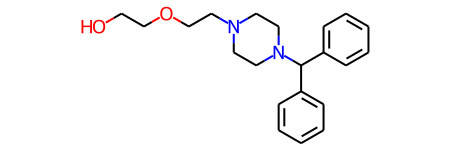

In [7]:
sdf[0]

## 3. Now, we can perform seed compound optimization

#### We will use settings, which we  have read from the config file. 


In [12]:
optimize(settings=settings,
                   input_config=input_config,
                   brute_force=False,
                   number_generations=0) # this parameter is used only if brute_force, otherwise ignored and value from settings is used

__________________________________________________ 
Generation 0: 2023-09-15 10:09:41.261515
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_0/input_dataset_Hs.sdf
Processing predictions ...
['ID_0_0'] selected all compds
Finding fragments has started
Descriptors calculation started. Please wait it can take some time
Fragment contribution for 231 started


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Fragment contribution for logbb started
Processing contributions ...
Model                                                 231
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.083988
         12      c1ccc(C(c2ccccc2)[*])cc1        1.188701
         13      OCCOCCN1CCN([*])CC1             1.292736
         14      c1ccc([*])cc1                   1.529403
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  1.528468
Model                                               logbb
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.060773
         12      c1ccc(C(c2ccccc2)[*])cc1        0.348591
         13      OCCOCCN1CCN([*])CC1             0.109077
         14      c1ccc([*])cc1                   0.137563
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  0.121537
Model Compound  Frag_id                        Fragment       231     logbb
11      ID_0_0       11                    

RDKit WARNING: [10:12:20] WARNING: not removing hydrogen atom with dummy atom neighbors


  Compound  Frag_id                                 Fragment   Average  \
0   ID_0_0        6     c1ccc(C(c2ccccc2)N2CCN(CC[*])CC2)cc1 -0.193056   
1   ID_0_0        4    c1ccc(C(c2ccccc2)N2CCN(CCO[*])CC2)cc1 -0.158952   
2   ID_0_0       10       c1ccc(C(c2ccccc2)N2CCN([*])CC2)cc1 -0.146220   
3   ID_0_0        8      c1ccc(C(c2ccccc2)N2CCN(C[*])CC2)cc1 -0.142663   
4   ID_0_0       12                 c1ccc(C(c2ccccc2)[*])cc1 -0.130526   
5   ID_0_0        0  c1ccc(C(c2ccccc2)N2CCN(CCOCC[*])CC2)cc1 -0.106963   

                                                 ids  
0  [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...  
1  [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...  
2  [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1...  
3  [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17...  
4  [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...  
5  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...  


...

__________________________________________________ 
Generation 2: 2023-09-15 10:15:52.964484
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_2/input_dataset_Hs.sdf
Processing predictions ...


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Index(['ID_2_2337', 'ID_2_3613', 'ID_2_1420', 'ID_2_190', 'ID_2_1421',
       'ID_2_2133', 'ID_2_1308', 'ID_2_40', 'ID_2_71', 'ID_2_2574'],
      dtype='object', name='id') best des
Optimizer reached number of fitted compounds specified in config.


SystemExit: 

/home/maria/anaconda3/envs/crem_ml/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### 4. Now  we can look at results
### in working directory we have a folder with the optimizer output: *out* 

In [13]:
settings_frozen['working_dir']

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN'

In [14]:
os.listdir(settings_frozen['working_dir']+"/out")  # there are 3 generations, as we defined in settings

['generation_0', 'generation_1', 'generation_2']

In [15]:
os.listdir(settings_frozen['working_dir'] + '/out//generation_2')  # let's look into the last generation

['input_dataset.sdf',
 'input_dataset_Hs.sdf',
 'output_match.sdf',
 'predictions_231.txt',
 'predictions_logbb.txt',
 'processed_predictions.sdf',
 'x.colnames',
 'x.rownames',
 'x.txt']

#### *output_match.sdf* is the file with compounds, having favorable  values of parameters (predicted).
#### Let' s look at them (in previous generations there might also be such compounds, but for now we will explore just last one)

In [16]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_2/output_match.sdf")

In [17]:
mols = []
for mol in sdf:
    mols.append(mol)

In [18]:
for m in mols:
    AllChem.Compute2DCoords(m)

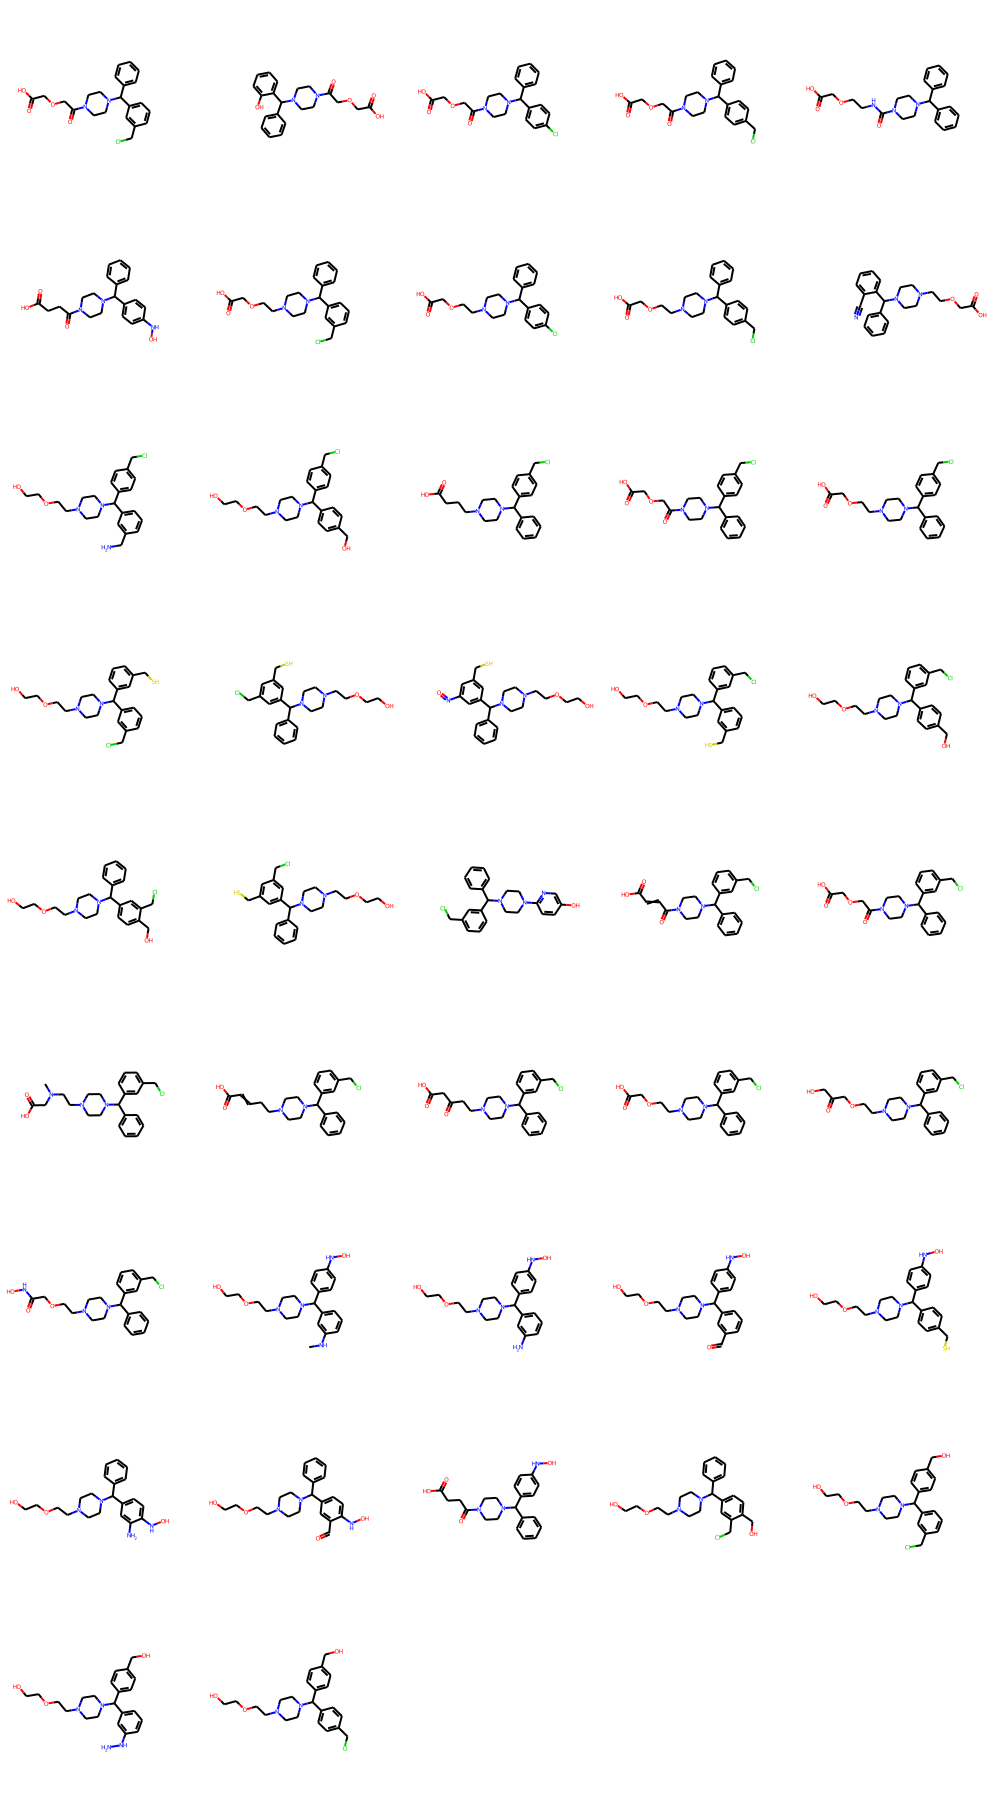

In [19]:
Draw.MolsToGridImage(mols, molsPerRow=5)

## We can recognize here a known antihistamine drug of 2nd generation in the results: cetirizine. 

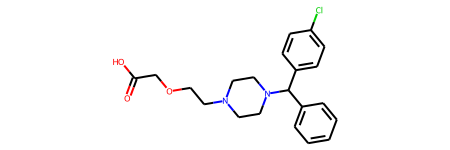

In [20]:
cetirizine = Chem.MolFromSmiles("OC(=O)COCCN1CCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1")
cetirizine

## Let's find it in our sdf file.  We can run similarity search based on ECFP  fingerprints (RDKIT)

In [21]:
cetirizine_ecfp = AllChem.GetMorganFingerprintAsBitVect(cetirizine ,radius=3)

In [23]:
for mol in mols:
    if  DataStructs.FingerprintSimilarity(AllChem.GetMorganFingerprintAsBitVect(mol,radius=3), cetirizine_ecfp) == 1:
        print(mol.GetPropsAsDict())

{'parent_name': 'ID_1_163', 'transformation': '[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[Cl]-[c:6](:[c:4]:[*:2]):[c:5]:[*:3]', 'protected_ids': '1,2,3,4,5,7,9,10,11,13,14,15,16,17,20,23,25,27,32', 'ID': 'ID_2_374', 'pred_231': ' 7.428', 'pred_logbb': ' 0.269'}



#### Lets compare predictions of our models and true activity data for this molecule, taken from the ChEMBL database. 
####  As we can see predicted values for  'ID_2_5314'  (cetirizine) H1 affinity is 7.42 (log units), and logBB is 0.269 (probability to cross BBB). True H1 activity is 8.2 and true ability to pass through BBB is low (class 0).
#### The predicted values for all generated molecules are in the properties dict above. They also can be found in the database file *output.db*, as well as in the pedictions_XXX.txt files for every generation (XXX is the name of parameter as in config.yaml).

## 5.  Conclusion:
### As we can see predicted values for  'ID_2_5314' are close to experimental data. This is a successsful result.

## 6. Now, let's perform the same task, but this time we will use *random compound selection*, to illustrate that the use of QSAR models in optimization really guides it to favorable compounds, while random selection may not work. 
### (Note, we will try fully random selection; however, in the case of partial randomness we  can get good results, see README.md)
 
#### We will use settings, which we  have read from the config file, but change "random_compound_selection" to 100%

In [75]:
settings_copy['random_compounds_selection'] = 1
# also, it's recommended to correct this value manually in the config.yaml after it is  saved by the program to working dir (for keeping track of experiments)

In [76]:
# let's  write results to a different folder
os.mkdir(settings_copy['working_dir'] + "_random_compounds")
settings_copy['working_dir'] = settings_copy['working_dir'] + "_random_compounds"
settings_copy['working_dir'] 

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds'

In [77]:
settings_copy

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 1,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounded_box': True,
 'smart_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'keep_stereo': False,
 'replacement_database': '/home/maria/pavel/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'output_format': 'svm',
 'num_of_generation': 5,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'store_all_files': True,
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,


In [78]:
optimize(settings=settings_copy,
                   input_config=input_config,
                   brute_force=False,
                   number_generations=0) # this parameter is used only if brute_force, otherwise ignored and value from settings is used

__________________________________________________ 
Generation 0: 2023-09-15 10:53:58.581247
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_0/input_dataset_Hs.sdf
Processing predictions ...
['ID_0_0'] selected all compds
10
Empty DataFrame
Columns: [231, logbb]
Index: [] pred_diff
Finding fragments has started
Descriptors calculation started. Please wait it can take some time
Fragment contribution for 231 started


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Fragment contribution for logbb started
Processing contributions ...
Model                                                 231
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.083988
         12      c1ccc(C(c2ccccc2)[*])cc1        1.188701
         13      OCCOCCN1CCN([*])CC1             1.292736
         14      c1ccc([*])cc1                   1.529403
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  1.528468
Model                                               logbb
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.060773
         12      c1ccc(C(c2ccccc2)[*])cc1        0.348591
         13      OCCOCCN1CCN([*])CC1             0.109077
         14      c1ccc([*])cc1                   0.137563
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  0.121537
Model Compound  Frag_id                        Fragment       231     logbb
11      ID_0_0       11                    

RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:02:03] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:02:02] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:

__________________________________________________ 
Generation 1: 2023-09-15 11:02:05.782136
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_1/input_dataset_Hs.sdf
Processing predictions ...
Index(['ID_1_205', 'ID_1_15', 'ID_1_87', 'ID_1_163', 'ID_1_34', 'ID_1_202',
       'ID_1_44', 'ID_1_217', 'ID_1_85', 'ID_1_70'],
      dtype='object', name='id') best des
[] best des -random (check the 'head')
10
             231   logbb
id                      
ID_1_0    7.2705  0.9095
ID_1_1    7.1115  0.8935
ID_1_2    6.9195  0.6835
ID_1_3    7.0605  0.8330
ID_1_4    7.0170  0.7685
...          ...     ...
ID_1_229  7.5480  0.8330
ID_1_232  7.2495  0.8520
ID_1_234  7.0205  0.7945
ID_1_235  7.1345  0.8155
ID_1_242  7.1595  0.8025

[195 rows x 2 columns] pred_diff
10 n_random
['ID_1_162', 'ID_1_20', 'ID_1_22', 'ID_1_61', 'ID_1_197', '

...

__________________________________________________ 
Generation 2: 2023-09-15 11:10:23.748231
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_2/input_dataset_Hs.sdf
Processing predictions ...


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Index(['ID_2_2410', 'ID_2_2206', 'ID_2_2565', 'ID_2_2322', 'ID_2_2165',
       'ID_2_2353', 'ID_2_2179', 'ID_2_2131', 'ID_2_2591', 'ID_2_2257'],
      dtype='object', name='id') best des
[] best des -random (check the 'head')
10
              231   logbb
id                       
ID_2_10    7.4685  0.8545
ID_2_1000  6.7090  0.7980
ID_2_1004  7.1265  0.8875
ID_2_1005  7.2810  0.8565
ID_2_1006  6.8660  0.8760
...           ...     ...
ID_2_992   7.0940  0.8740
ID_2_994   7.0890  0.8140
ID_2_996   6.9035  0.7275
ID_2_998   6.9715  0.8125
ID_2_999   7.1110  0.7775

[2145 rows x 2 columns] pred_diff
10 n_random
['ID_2_2744', 'ID_2_2033', 'ID_2_565', 'ID_2_42', 'ID_2_1854', 'ID_2_1048', 'ID_2_47', 'ID_2_1137', 'ID_2_2446', 'ID_2_293']
Optimizer reached number of fitted compounds specified in config.


SystemExit: 

/home/maria/anaconda3/envs/crem_ml/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [79]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//out/generation_2/output_match.sdf")
mols = []
for mol in sdf:
    mols.append(mol)
for m in mols:
    AllChem.Compute2DCoords(m)

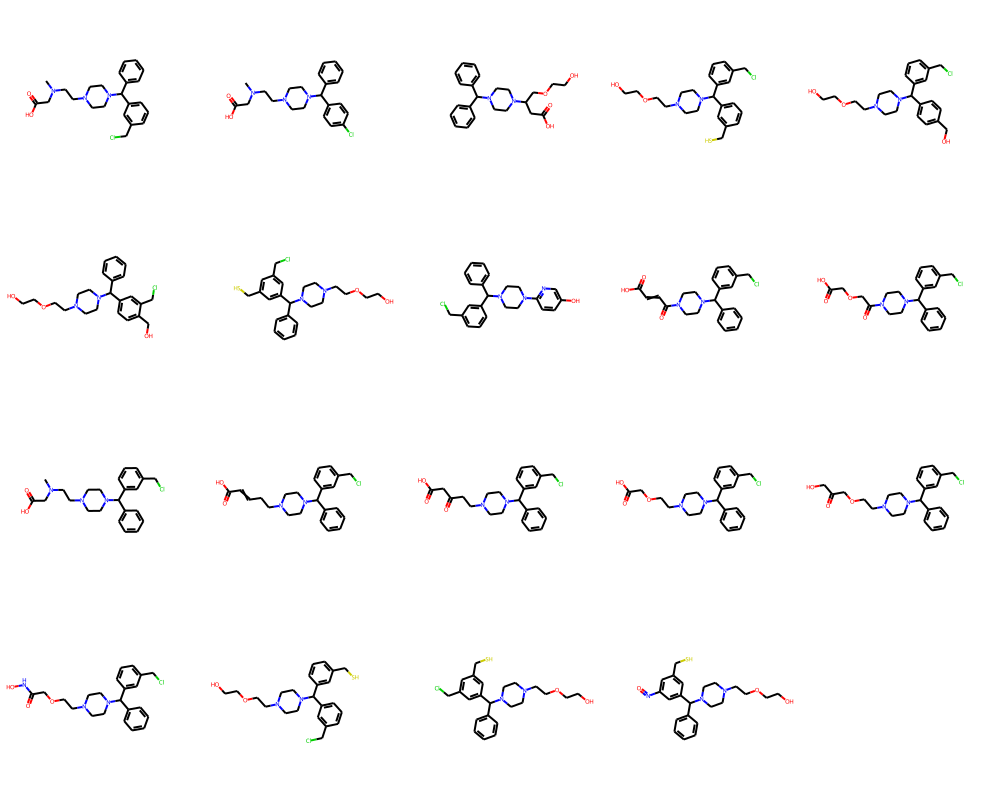

In [80]:
Draw.MolsToGridImage(mols, molsPerRow=5)

### It looks like we don't have cetirizine among the results. However, let's check the whole generated database. Main table of the database is called optimizer_table, and we will use sqlite python module to connect to it

In [81]:
con = sqlite3.connect("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//output.db")

In [82]:
sql_query = """SELECT * FROM optimizer_table"""

In [83]:
df = pd.read_sql_query(sql_query,con)

In [84]:
df

,id,smi,generation,parent,transformation,fit,predicted_231,predicted_logbb
0,ID_0_0,OCCOCCN1CCN(C(c2ccccc2)c2ccccc2)CC1,0,None,None,0,7.2705,0.9095
1,ID_1_0,[H]OC([H])([H])C([H])([H])OCC([H])([H])N1C([H]...,1,ID_0_0,[CH2](-[CH2:7]-[N:9](-[!#1:4])-[!#1:5])-[O:8]-...,0,7.2705,0.9095
2,ID_1_1,[H]OC([H])([H])C([H])([H])OCCC([H])([H])N1C([H...,1,ID_0_0,[CH2](-[CH2:7]-[N:9](-[!#1:4])-[!#1:5])-[O:8]-...,0,7.1115,0.8935
3,ID_1_2,[H]OC([H])([H])C([H])([H])OC(=O)C([H])([H])N1C...,1,ID_0_0,[CH2](-[CH2:7]-[N:9](-[!#1:4])-[!#1:5])-[O:8]-...,0,6.9195,0.6835
4,ID_1_3,[H]OC([H])([H])C([H])([H])OC(=O)CC([H])([H])N1...,1,ID_0_0,[CH2](-[CH2:7]-[N:9](-[!#1:4])-[!#1:5])-[O:8]-...,0,7.0605,0.8330
...,...,...,...,...,...,...,...,...
3060,ID_2_2815,[H]ON=C(C)C([H])([H])OC([H])([H])C([H])([H])N1...,2,ID_1_34,[CH2](-[OH:4])-[CH2:5]-[O:6]-[!#1:3]>>[CH3]-[C...,0,7.2645,0.7525
3061,ID_2_2816,[H]OCC(=O)C([H])([H])OC([H])([H])C([H])([H])N1...,2,ID_1_34,[CH2](-[OH:4])-[CH2:5]-[O:6]-[!#1:3]>>[O]=[C](...,0,7.1420,0.7755
3062,ID_2_2817,[H]ONC(=O)C([H])([H])OC([H])([H])C([H])([H])N1...,2,ID_1_34,[CH2](-[OH:4])-[CH2:5]-[O:6]-[!#1:3]>>[O]=[C](...,0,7.2370,0.7270
3063,ID_2_2818,[H]ONC(=O)OC([H])([H])C([H])([H])N1C([H])([H])...,2,ID_1_34,[CH2](-[CH2]-[O:6]-[CH2:5]-[!#1:2])-[OH:4]>>[O...,0,7.0995,0.6430


In [85]:
# to quickly find cetirizine in this table, we can run similarity search based on ECFP  fingerprints from RDKIT

In [86]:
df["ecfp"] = df.smi.apply(lambda x: AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), radius=3))

In [87]:
df["ecfp_sim"] = df.ecfp.apply(lambda x: DataStructs.FingerprintSimilarity(x, cetirizine_ecfp))

### Let's sort our table from the most to the least similar to cetirizine.

In [88]:
df.sort_values("ecfp_sim", ascending=False)

,id,smi,generation,parent,transformation,fit,predicted_231,predicted_logbb,ecfp,ecfp_sim
164,ID_1_163,[H]OC(=O)C([H])([H])OC([H])([H])C([H])([H])N1C...,1,ID_0_0,[CH2](-[OH:4])-[CH2:5]-[O:6]-[!#1:3]>>[O]=[C](...,0,7.3485,0.6645,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.830508
477,ID_2_232,[H]OC(=O)COC([H])([H])C([H])([H])N1C([H])([H])...,2,ID_1_197,[O]=[C](-[CH2]-[CH2:6]-[CH2:5]-[!#1:2])-[NH]-[...,0,7.3485,0.6645,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.830508
972,ID_2_727,[H]ON=C(C([H])([H])[H])C([H])([H])OC([H])([H])...,2,ID_1_162,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[C...,0,7.4685,0.8640,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.732394
70,ID_1_69,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[C...,0,7.5290,0.9355,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.731343
714,ID_2_469,[H]OC(=O)C([H])([H])OCC([H])([H])C([H])([H])N1...,2,ID_1_212,[CH3]-[N](-[CH2:7]-[CH2:6]-[!#1:1])-[CH2:8]-[C...,0,7.5480,0.8330,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.666667
...,...,...,...,...,...,...,...,...,...,...
2965,ID_2_2720,[H]OC([H])([H])C([H])([H])CNC(=S)N1C([H])([H])...,2,ID_1_34,[CH2](-[CH2]-[N:10](-[CH2:8]-[!#1:3])-[CH2:9]-...,0,7.0260,0.6485,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",0.250000
1403,ID_2_1158,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])(N...,2,ID_1_61,[H]-[CH2:6](-[CH2:5]-[!#1:1])-[N:7](-[!#1:3])-...,0,7.6325,0.9040,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.250000
2251,ID_2_2006,[H]OC([H])([H])C([H])([H])CNC(=S)N1C([H])([H])...,2,ID_1_22,[CH2](-[CH2]-[N:10](-[CH2:8]-[!#1:3])-[CH2:9]-...,0,7.0180,0.7610,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",0.247525
2012,ID_2_1767,[H]OC([H])([H])C([H])([H])CNC(=S)N1C([H])([H])...,2,ID_1_20,[CH2](-[CH2]-[N:10](-[CH2:8]-[!#1:3])-[CH2:9]-...,0,7.0190,0.8440,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",0.247525


## Conclusion:
### So, there's no compound with 100% similarity to cetirizine, so  there is no cetirizine. This means it was helpful to perform QSAR guided fcompound selection versus random.